# All runs combined - intra-chain and no-contact asa_nz from the AlphaFold monomer

Groups: Inter PDB (multimer asa_nz over the chain copies with the inter-chain contact), **Intra AF** (AlphaFold intra-chain contact, monomer asa_nz) and **No contact AF** (no contact within 4.5 A in the AlphaFold monomer, monomer asa_nz). Inter PDB always uses the multimer.

Every figure combines the five runs:
- **row 1**: asa_nz histograms for **max** (max of max over chain copies and lysines), **min** (min of min) and **avg**
  (average over lysines of the per-lysine mean)
- **row 2**: scatter of MS_DSA vs asa_nz (all runs on one plot) and the MS_DSA histogram
- **row 3**: B-factor z-score histograms (PDB; NZ max of max, NZ min of min, residue average)

Histograms: for each run, each group's peptides are binned and normalized to percent within the group; the bars are the
mean of these percentages over the runs and the error bars their standard deviation. Legends give the number of
peptides summed over runs. The MS_DSA and B-factor histograms count the group's peptides that have a value in that column.

Comparisons: intra **may also be inter-chain**, or **purely intra** (no lysine of the peptide with an inter-chain bond).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dsa.ms_dsa.evaluation1.ms_dsa_annotator import MSDSAAnnotator
from dsa.ms_dsa.evaluation1.lysine_properties import CONTACT_CLASSES
from dsa.ms_dsa.evaluation1.plots import (contact_class_summary_figure, source_groups, pooled_correlations,
                                          group_sizes, BFACTOR_STATISTIC_COLUMNS)

plt.rcParams.update({"font.size": 8, "figure.dpi": 100})
ms_dsa_by_run = {run_index: MSDSAAnnotator.load_run(run_index) for run_index in range(5)}

In [2]:
# settings
sasa_source = "monomer"              # "monomer" or "multimer": source of the intra-chain and no-contact asa_nz
dsa_column = "MS_DSA_shared_charges"
contact_class = "salt_bridge"          # one of CONTACT_CLASSES
scatter_statistic = "max"             # asa_nz statistic of the scatter plot
versions = {
    "A. zero areas included": ["channel_absent", "no_shared_charges"],
    "B. zero areas excluded": ["channel_absent", "no_shared_charges", "zero_area_shared"],
}
comparisons = {"intra may also be inter": False, "purely intra": True}

sasa_bins = [*np.arange(0.0, 61.0, 10.0), np.inf]                           # width 10
dsa_bins = [0.0, *np.linspace(0.1, 0.9, 4), *np.linspace(0.9, 1.0, 4)[1:]]  # 0-0.1, 3 bins over 0.1-0.9, 3 over 0.9-1
bfactor_bins = [-np.inf, *np.arange(-3.0, 5.5, 1.0), np.inf]                 # z-scores, width 1

In [3]:
# peptides per group (asa_nz max available, shared-charge MS_DSA, version A), summed over runs, for every class
pd.DataFrame({c: group_sizes(ms_dsa_by_run, source_groups(c, sasa_source, "max"), dsa_column,
                             versions["A. zero areas included"]).sum() for c in CONTACT_CLASSES}).T

,Inter PDB,Intra AF,No contact AF
dist4.5,1537,4155,3308
salt_bridge,541,2230,3308
hydrogen_bond,1039,2871,3308
cation_pi,187,304,3308
covalent_isopeptide,0,0,3308
any_bond,1082,3008,3308


## A. zero areas included

A. zero areas included, salt_bridge, intra may also be inter: Spearman correlation with MS_DSA_shared_charges (all runs pooled)


,Inter PDB,Intra AF,No contact AF
asa_nz max,-0.016,0.056,0.014
asa_nz min,-0.074,-0.000,-0.030
asa_nz avg,-0.046,0.034,-0.017
nz_bfactor_z_max_max,0.070,0.009,-0.010
nz_bfactor_z_min_min,-0.098,0.026,0.028
avg_bfactor_z_mean_avg,-0.052,0.022,-0.061


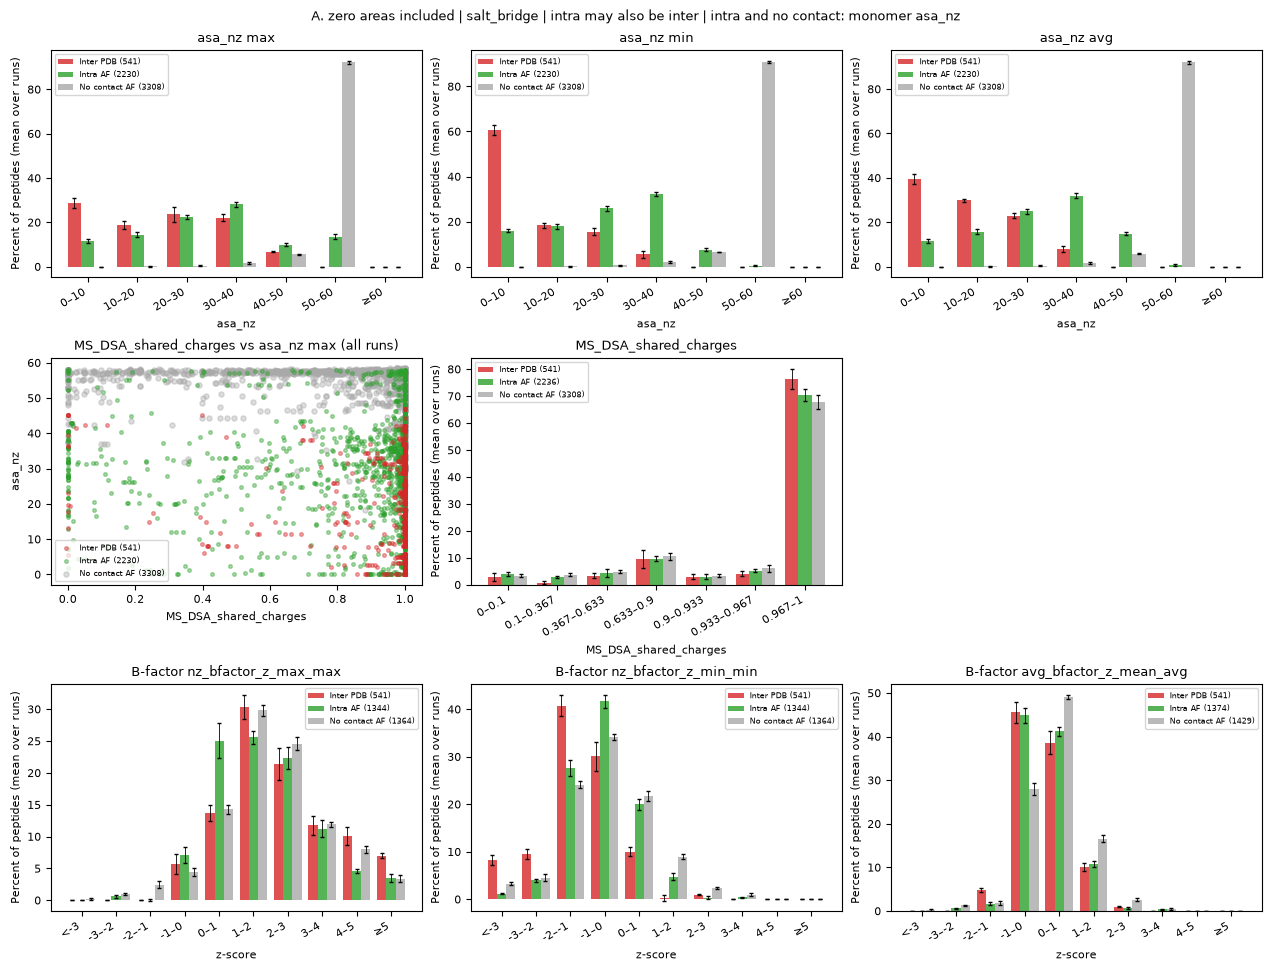

A. zero areas included, salt_bridge, purely intra: Spearman correlation with MS_DSA_shared_charges (all runs pooled)


,Inter PDB,Intra AF,No contact AF
asa_nz max,-0.016,0.066,0.014
asa_nz min,-0.074,0.011,-0.030
asa_nz avg,-0.046,0.047,-0.017
nz_bfactor_z_max_max,0.070,-0.022,-0.010
nz_bfactor_z_min_min,-0.098,0.038,0.028
avg_bfactor_z_mean_avg,-0.052,-0.018,-0.061


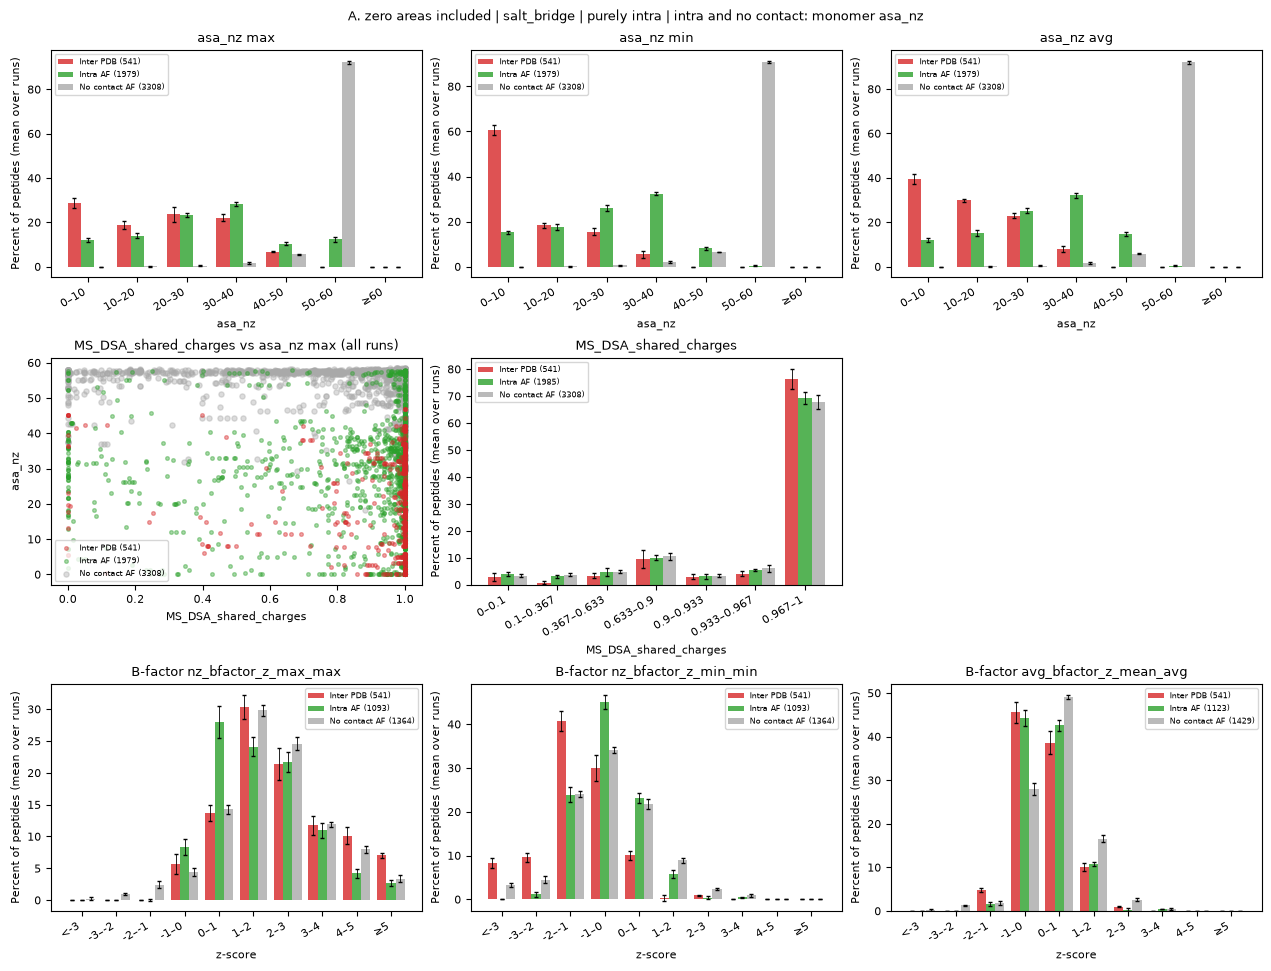

In [4]:
version = "A. zero areas included"
for comparison, purely_intra in comparisons.items():
    exclude = versions[version]
    correlations = {f"asa_nz {s}": pooled_correlations(ms_dsa_by_run, source_groups(contact_class, sasa_source, s, purely_intra), dsa_column, exclude)
                    for s in ("max", "min", "avg")}
    correlations.update({column: pooled_correlations(ms_dsa_by_run, source_groups(contact_class, sasa_source, purely_intra=purely_intra, value_column=column), dsa_column, exclude)
                         for column in BFACTOR_STATISTIC_COLUMNS.values()})
    print(f"{version}, {contact_class}, {comparison}: Spearman correlation with {dsa_column} (all runs pooled)")
    display(pd.DataFrame(correlations).T)
    contact_class_summary_figure(ms_dsa_by_run, contact_class, sasa_source, purely_intra, exclude, sasa_bins, dsa_bins,
                                 bfactor_bins, dsa_column=dsa_column, scatter_statistic=scatter_statistic,
                                 suptitle=f"{version} | {contact_class} | {comparison} | intra and no contact: {sasa_source} asa_nz")
    plt.show()

## B. zero areas excluded

B. zero areas excluded, salt_bridge, intra may also be inter: Spearman correlation with MS_DSA_shared_charges (all runs pooled)


,Inter PDB,Intra AF,No contact AF
asa_nz max,0.117,0.022,-0.052
asa_nz min,0.019,0.003,-0.043
asa_nz avg,0.126,0.007,-0.046
nz_bfactor_z_max_max,0.188,-0.010,0.086
nz_bfactor_z_min_min,-0.234,-0.178,-0.139
avg_bfactor_z_mean_avg,0.013,-0.102,-0.057


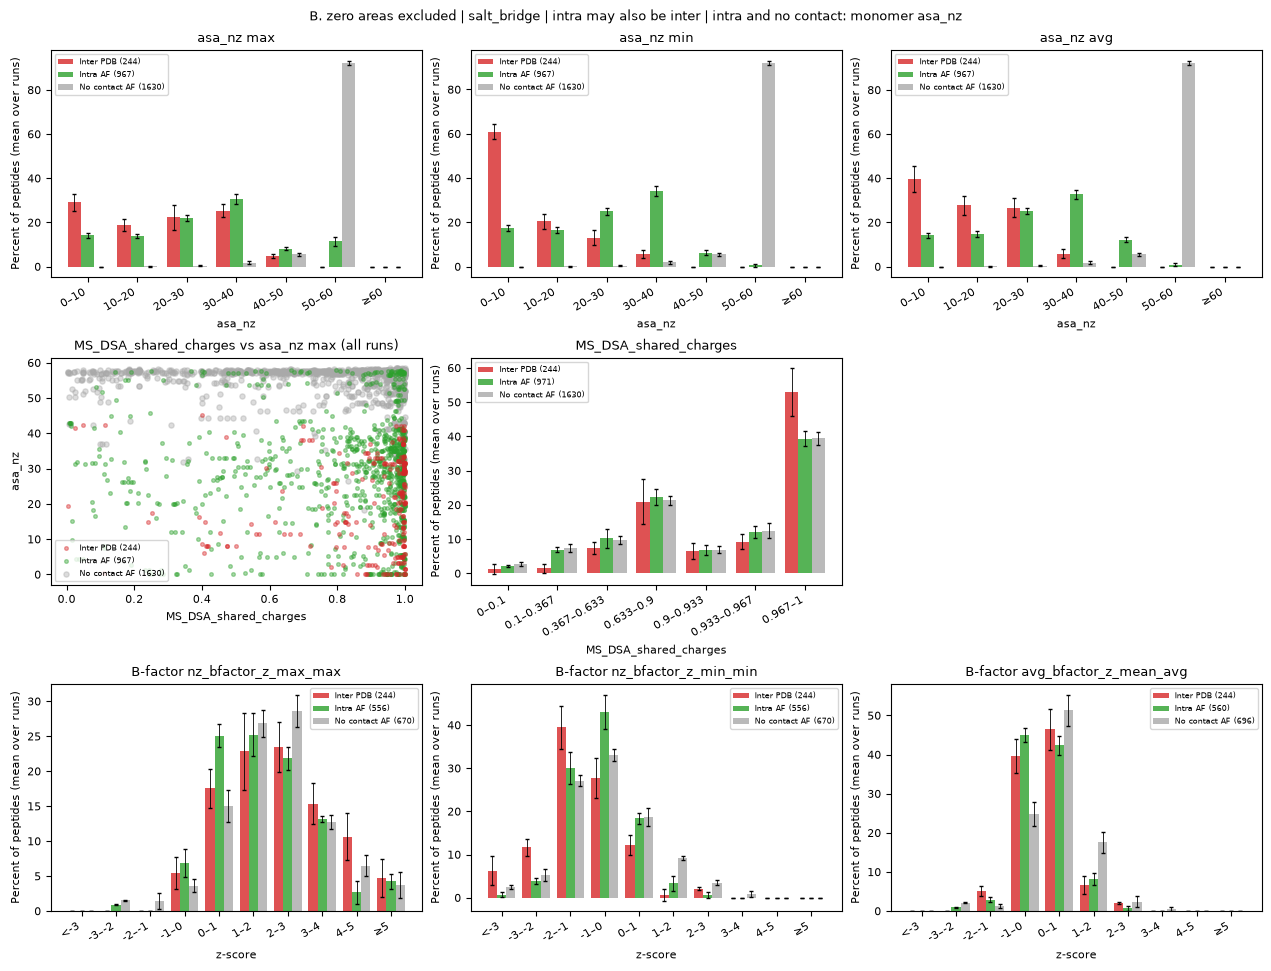

B. zero areas excluded, salt_bridge, purely intra: Spearman correlation with MS_DSA_shared_charges (all runs pooled)


,Inter PDB,Intra AF,No contact AF
asa_nz max,0.117,0.031,-0.052
asa_nz min,0.019,-0.000,-0.043
asa_nz avg,0.126,0.006,-0.046
nz_bfactor_z_max_max,0.188,-0.010,0.086
nz_bfactor_z_min_min,-0.234,-0.141,-0.139
avg_bfactor_z_mean_avg,0.013,-0.084,-0.057


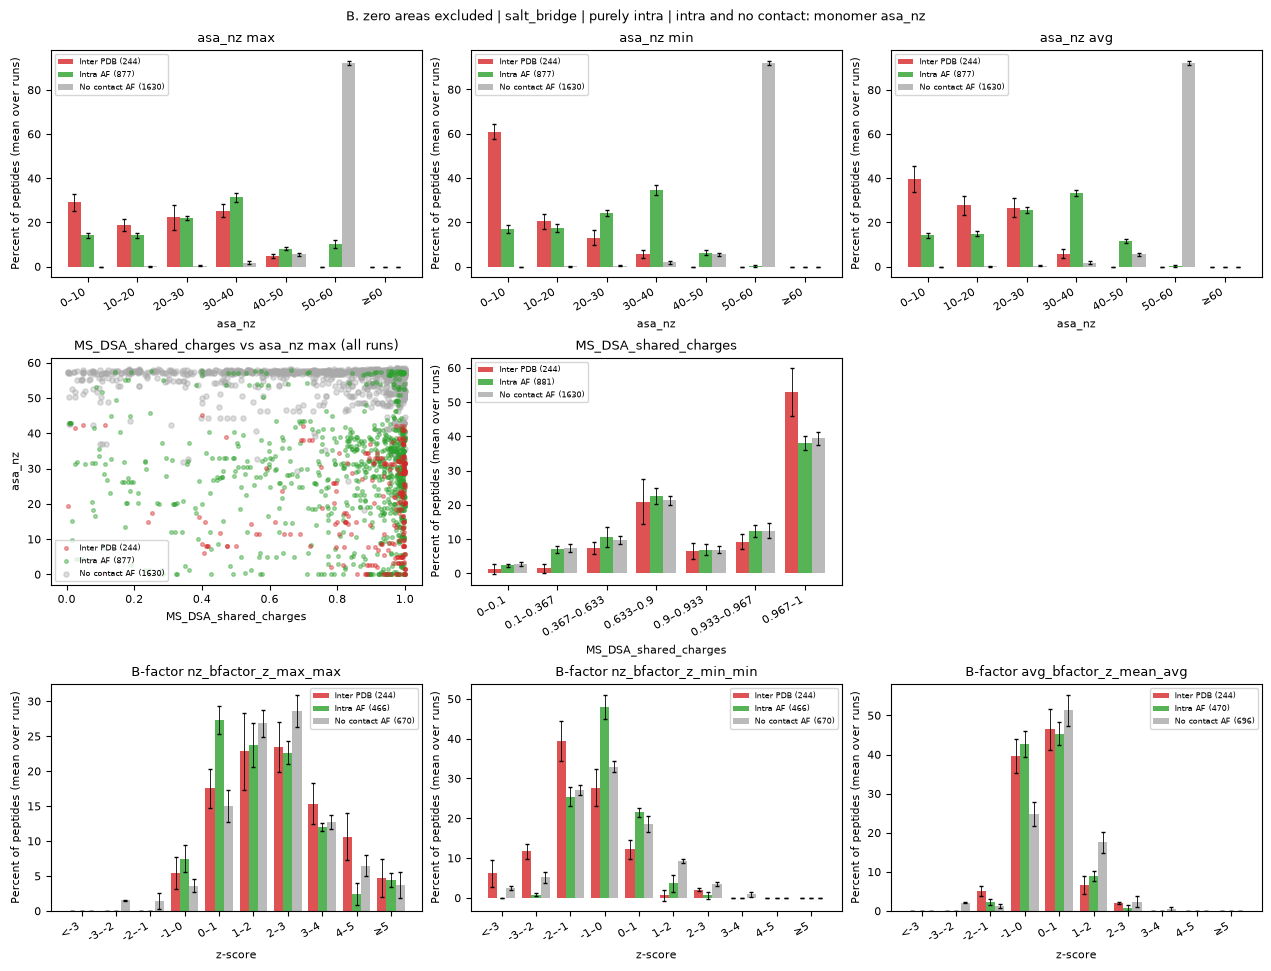

In [5]:
version = "B. zero areas excluded"
for comparison, purely_intra in comparisons.items():
    exclude = versions[version]
    correlations = {f"asa_nz {s}": pooled_correlations(ms_dsa_by_run, source_groups(contact_class, sasa_source, s, purely_intra), dsa_column, exclude)
                    for s in ("max", "min", "avg")}
    correlations.update({column: pooled_correlations(ms_dsa_by_run, source_groups(contact_class, sasa_source, purely_intra=purely_intra, value_column=column), dsa_column, exclude)
                         for column in BFACTOR_STATISTIC_COLUMNS.values()})
    print(f"{version}, {contact_class}, {comparison}: Spearman correlation with {dsa_column} (all runs pooled)")
    display(pd.DataFrame(correlations).T)
    contact_class_summary_figure(ms_dsa_by_run, contact_class, sasa_source, purely_intra, exclude, sasa_bins, dsa_bins,
                                 bfactor_bins, dsa_column=dsa_column, scatter_statistic=scatter_statistic,
                                 suptitle=f"{version} | {contact_class} | {comparison} | intra and no contact: {sasa_source} asa_nz")
    plt.show()